# Eye Health Classification Project

Leveraging deep learning, this project automates the multi-class classification of critical retinal conditions—including Diabetic Retinopathy, Glaucoma, Cataracts, and AMD—to facilitate early detection and prevent irreversible vision loss.

<img src='https://media.allaboutvision.com/cms/caas/v1/media/1352436/data/75ecb70fb0da82081c21804ba85238b8' width='750'>

In [1]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

# EDA

In [2]:
df=pd.read_csv('patient_data.csv')

In [3]:
df.head()

,name,age,has_eye_disease,has_diabetic_retinopathy,sugar_percentage,glucose_percentage,cholesterol_percentage,obesity_percentage,blood_pressure,heart_rate
0,Patient 1,39,False,False,5.70,147.48,164.45,32.94,122/63,94
1,Patient 2,67,True,False,8.72,91.52,235.62,39.58,92/80,68
2,Patient 3,44,True,False,13.83,160.17,299.13,38.45,140/60,67
3,Patient 4,46,True,True,9.48,106.84,236.75,29.10,132/83,82
4,Patient 5,39,False,False,5.60,158.65,182.11,16.25,128/72,63


In [4]:
df.tail()

,name,age,has_eye_disease,has_diabetic_retinopathy,sugar_percentage,glucose_percentage,cholesterol_percentage,obesity_percentage,blood_pressure,heart_rate
19995,Patient 19996,45,False,False,7.78,157.15,213.97,27.25,123/65,65
19996,Patient 19997,59,False,False,9.95,116.91,165.76,33.10,99/61,95
19997,Patient 19998,80,False,False,5.59,147.15,248.27,15.36,122/76,60
19998,Patient 19999,79,True,False,7.51,150.61,206.42,39.94,120/62,66
19999,Patient 20000,49,True,True,4.15,168.89,131.34,34.04,109/69,96


In [5]:
df.shape

(20000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      20000 non-null  object 
 1   age                       20000 non-null  int64  
 2   has_eye_disease           20000 non-null  bool   
 3   has_diabetic_retinopathy  20000 non-null  bool   
 4   sugar_percentage          20000 non-null  float64
 5   glucose_percentage        20000 non-null  float64
 6   cholesterol_percentage    20000 non-null  float64
 7   obesity_percentage        20000 non-null  float64
 8   blood_pressure            20000 non-null  object 
 9   heart_rate                20000 non-null  int64  
dtypes: bool(2), float64(4), int64(2), object(2)
memory usage: 1.3+ MB


In [7]:
bool_map = {True: 1, False: 0}
df['has_eye_disease'] = df['has_eye_disease'].map(bool_map)
df['has_diabetic_retinopathy'] = df['has_diabetic_retinopathy'].map(bool_map)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      20000 non-null  object 
 1   age                       20000 non-null  int64  
 2   has_eye_disease           20000 non-null  int64  
 3   has_diabetic_retinopathy  20000 non-null  int64  
 4   sugar_percentage          20000 non-null  float64
 5   glucose_percentage        20000 non-null  float64
 6   cholesterol_percentage    20000 non-null  float64
 7   obesity_percentage        20000 non-null  float64
 8   blood_pressure            20000 non-null  object 
 9   heart_rate                20000 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 1.5+ MB


In [9]:
df.isnull().sum()

name                        0
age                         0
has_eye_disease             0
has_diabetic_retinopathy    0
sugar_percentage            0
glucose_percentage          0
cholesterol_percentage      0
obesity_percentage          0
blood_pressure              0
heart_rate                  0
dtype: int64

In [10]:
df.drop(columns=['name'], inplace=True)

In [11]:
# Split 'blood_pressure' by '/' and convert to integer
df[['systolic_bp', 'diastolic_bp']] = df['blood_pressure'].str.split('/', expand=True).astype(int)

# Drop the original string column
df.drop(columns=['blood_pressure'], inplace=True)

In [12]:
#Feaute Engineering
# 1. Pulse Pressure (Difference between Systolic and Diastolic BP)
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

# 2. Mean Arterial Pressure (MAP)
df['map_bp'] = (df['systolic_bp'] + 2 * df['diastolic_bp']) / 3

# 3. Age & Glucose interaction
df['age_glucose_ratio'] = df['age'] * df['glucose_percentage']

# 4. Age & Systolic BP interaction
df['age_sys_bp'] = df['age'] * df['systolic_bp']

# 5. Composite Metabolic Risk Score
df['metabolic_risk_score'] = (df['glucose_percentage'] * 0.4) + (df['cholesterol_percentage'] * 0.4) + (df['obesity_percentage'] * 0.2)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       20000 non-null  int64  
 1   has_eye_disease           20000 non-null  int64  
 2   has_diabetic_retinopathy  20000 non-null  int64  
 3   sugar_percentage          20000 non-null  float64
 4   glucose_percentage        20000 non-null  float64
 5   cholesterol_percentage    20000 non-null  float64
 6   obesity_percentage        20000 non-null  float64
 7   heart_rate                20000 non-null  int64  
 8   systolic_bp               20000 non-null  int64  
 9   diastolic_bp              20000 non-null  int64  
 10  pulse_pressure            20000 non-null  int64  
 11  map_bp                    20000 non-null  float64
 12  age_glucose_ratio         20000 non-null  float64
 13  age_sys_bp                20000 non-null  int64  
 14  metabo

In [14]:
df.describe()

,age,has_eye_disease,has_diabetic_retinopathy,sugar_percentage,glucose_percentage,cholesterol_percentage,obesity_percentage,heart_rate,systolic_bp,diastolic_bp,pulse_pressure,map_bp,age_glucose_ratio,age_sys_bp,metabolic_risk_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,54.924350,0.49350,0.245500,9.481480,135.056622,199.907359,27.492396,79.915700,115.013350,75.037000,39.976350,88.362450,7423.328311,6319.160300,139.484072
std,14.624655,0.49997,0.430394,3.178785,37.613572,58.094403,7.218316,11.777238,14.672441,8.947063,17.217268,7.697565,2929.587043,1884.708736,27.858563
min,30.000000,0.00000,0.000000,4.000000,70.010000,100.020000,15.000000,60.000000,90.000000,60.000000,0.000000,70.000000,2104.500000,2700.000000,72.422000
25%,42.000000,0.00000,0.000000,6.720000,102.520000,149.207500,21.230000,70.000000,102.000000,67.000000,27.000000,82.666667,5176.185000,4800.000000,119.038500
50%,55.000000,0.00000,0.000000,9.460000,135.280000,199.760000,27.460000,80.000000,115.000000,75.000000,40.000000,88.333333,6926.410000,6200.000000,139.463000
75%,67.000000,1.00000,0.000000,12.230000,167.705000,250.202500,33.770000,90.000000,128.000000,83.000000,53.000000,94.000000,9374.375000,7680.000000,160.148500
max,80.000000,1.00000,1.000000,15.000000,200.000000,300.000000,40.000000,100.000000,140.000000,90.000000,80.000000,106.666667,15999.200000,11200.000000,207.586000


In [15]:
df.corr(numeric_only=True)

,age,has_eye_disease,has_diabetic_retinopathy,sugar_percentage,glucose_percentage,cholesterol_percentage,obesity_percentage,heart_rate,systolic_bp,diastolic_bp,pulse_pressure,map_bp,age_glucose_ratio,age_sys_bp,metabolic_risk_score
age,1.000000,-0.003524,-0.003508,-0.003715,0.009874,0.005322,0.010362,-0.006732,0.009912,0.001545,0.007644,0.007495,0.681143,0.896906,0.010309
has_eye_disease,-0.003524,1.000000,0.577886,0.000819,0.001913,-0.005085,0.002514,-0.018011,0.004200,0.000747,0.003191,0.003248,0.001375,-0.000114,-0.003078
has_diabetic_retinopathy,-0.003508,0.577886,1.000000,0.010569,-0.000295,-0.012299,-0.003079,-0.007153,-0.001026,0.011145,-0.006666,0.007985,-0.000452,-0.002295,-0.010578
sugar_percentage,-0.003715,0.000819,0.010569,1.000000,-0.002859,0.002267,0.014711,0.009119,0.000960,-0.008406,0.005187,-0.005903,-0.004989,-0.003589,0.001109
glucose_percentage,0.009874,0.001913,-0.000295,-0.002859,1.000000,0.010312,-0.002564,-0.007340,-0.002508,0.000744,-0.002524,-0.001017,0.714326,0.008638,0.548534
cholesterol_percentage,0.005322,-0.005085,-0.012299,0.002267,0.010312,1.000000,0.008310,0.000878,-0.011306,-0.002923,-0.008116,-0.009448,0.010230,-0.001340,0.840133
obesity_percentage,0.010362,0.002514,-0.003079,0.014711,-0.002564,0.008310,1.000000,0.000624,0.003038,0.000867,0.002139,0.002602,0.001967,0.010858,0.057368
heart_rate,-0.006732,-0.018011,-0.007153,0.009119,-0.007340,0.000878,0.000624,1.000000,0.000770,-0.000551,0.000943,0.000062,-0.010225,-0.006327,-0.003199
systolic_bp,0.009912,0.004200,-0.001026,0.000960,-0.002508,-0.011306,0.003038,0.000770,1.000000,-0.004204,0.854378,0.632114,0.006396,0.436240,-0.010628
diastolic_bp,0.001545,0.000747,0.011145,-0.008406,0.000744,-0.002923,0.000867,-0.000551,-0.004204,1.000000,-0.523239,0.772211,0.005327,-0.000913,-0.001991


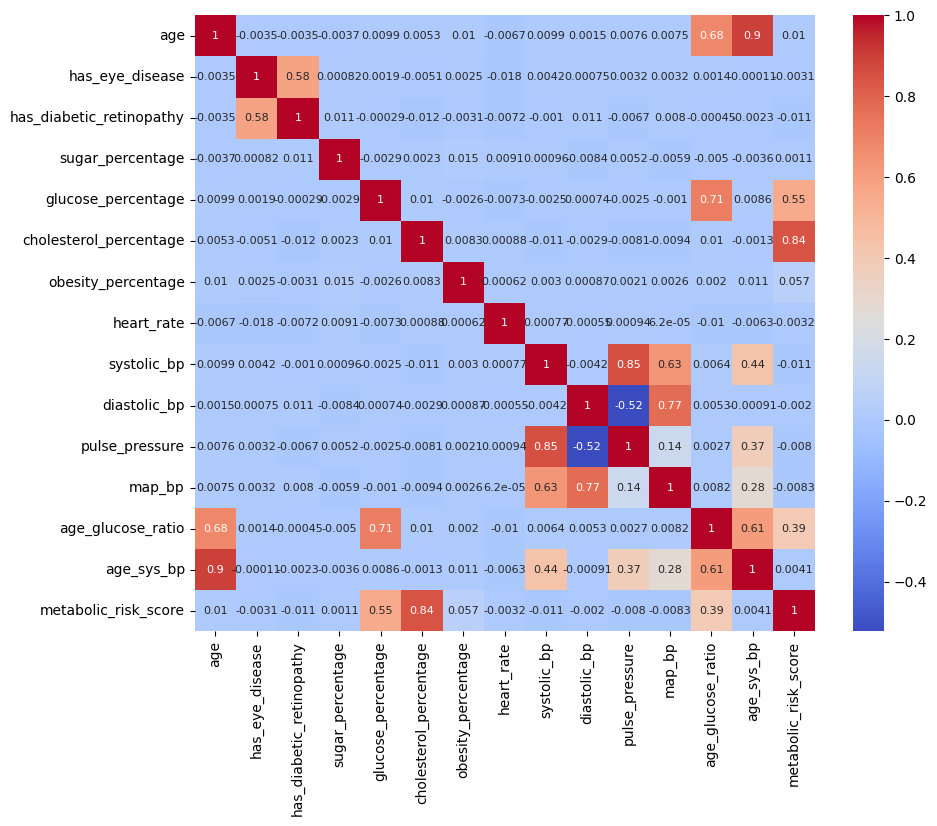

In [16]:
plt.figure(figsize=(10, 8));
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm', annot_kws={"size": 8}); plt.show()

In [17]:
df.columns

Index(['age', 'has_eye_disease', 'has_diabetic_retinopathy',
       'sugar_percentage', 'glucose_percentage', 'cholesterol_percentage',
       'obesity_percentage', 'heart_rate', 'systolic_bp', 'diastolic_bp',
       'pulse_pressure', 'map_bp', 'age_glucose_ratio', 'age_sys_bp',
       'metabolic_risk_score'],
      dtype='object')

In [18]:
df['age'].value_counts()

age
67    436
50    430
49    429
66    428
60    427
80    426
69    421
61    418
45    415
37    411
54    411
30    407
44    407
51    406
42    406
46    405
74    404
40    403
57    402
47    401
55    401
52    400
34    399
64    398
32    394
78    391
63    390
43    390
48    389
39    388
77    385
53    383
59    381
58    379
33    377
76    376
36    375
70    374
72    372
35    371
75    371
68    369
65    369
71    369
56    367
31    367
41    366
38    366
73    360
79    346
62    344
Name: count, dtype: int64

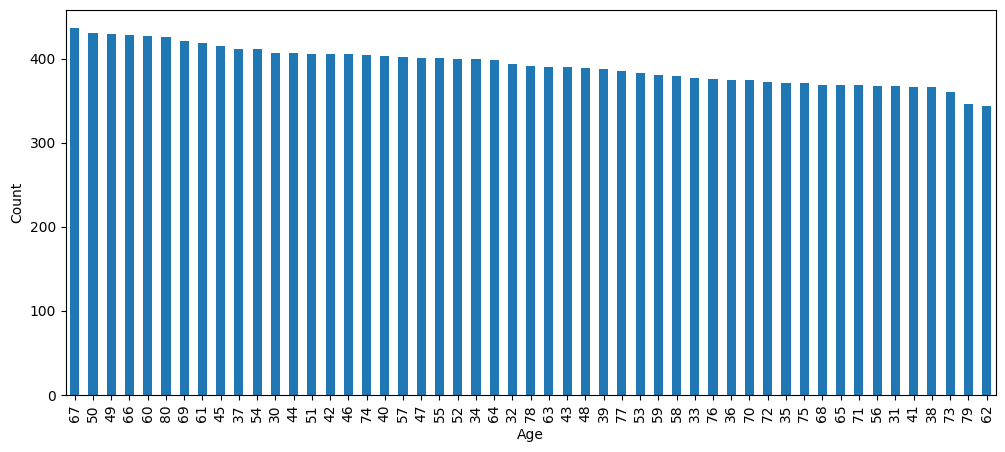

In [19]:
df['age'].value_counts().plot(kind='bar', figsize=(12, 5))
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [20]:
df['has_eye_disease'].value_counts()

has_eye_disease
0    10130
1     9870
Name: count, dtype: int64

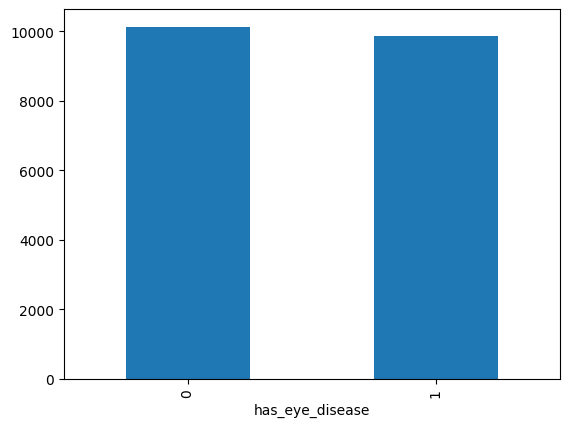

In [21]:
df['has_eye_disease'].value_counts().plot(kind='bar')
plt.show()

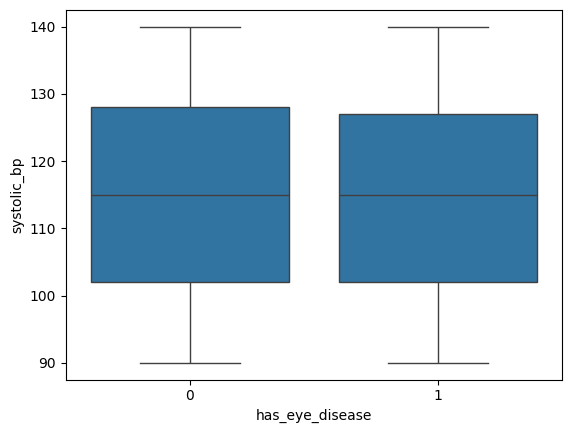

In [22]:
import seaborn as sns, matplotlib.pyplot as plt

# Box plot to compare systolic blood pressure levels between patients with and without eye disease
sns.boxplot(data=df, x='has_eye_disease', y='systolic_bp'); plt.show()

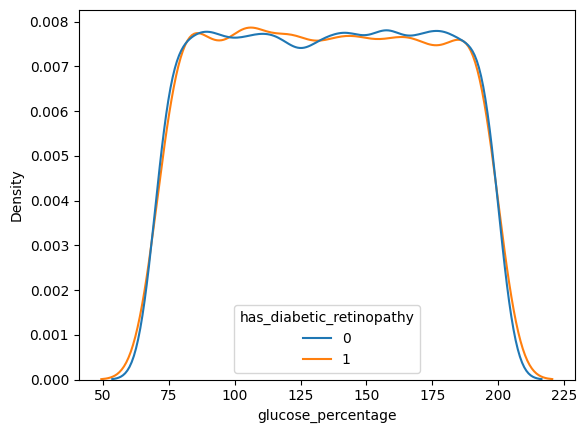

In [23]:
# Density plot showing glucose percentage distribution categorized by diabetic retinopathy status
sns.kdeplot(data=df, x='glucose_percentage', hue='has_diabetic_retinopathy', common_norm=False); plt.show()

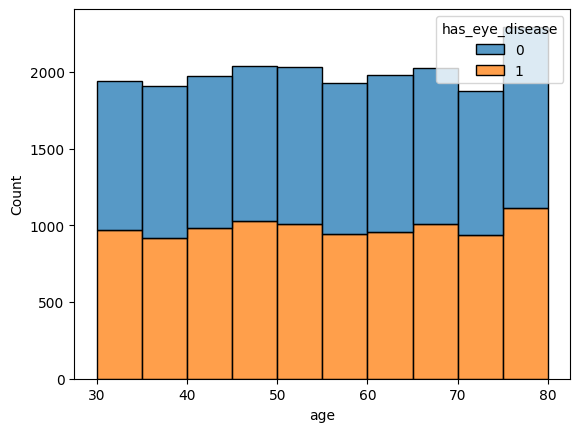

In [24]:
# Stacked histogram displaying eye disease prevalence across different age groups
sns.histplot(data=df, x='age', hue='has_eye_disease', multiple='stack', bins=10); plt.show()

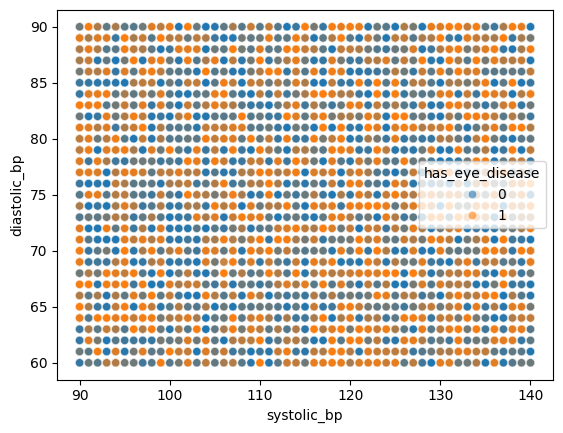

In [25]:
# Scatter plot analyzing relationship between systolic and diastolic BP colored by eye disease status
sns.scatterplot(data=df, x='systolic_bp', y='diastolic_bp', hue='has_eye_disease', alpha=0.6); plt.show()

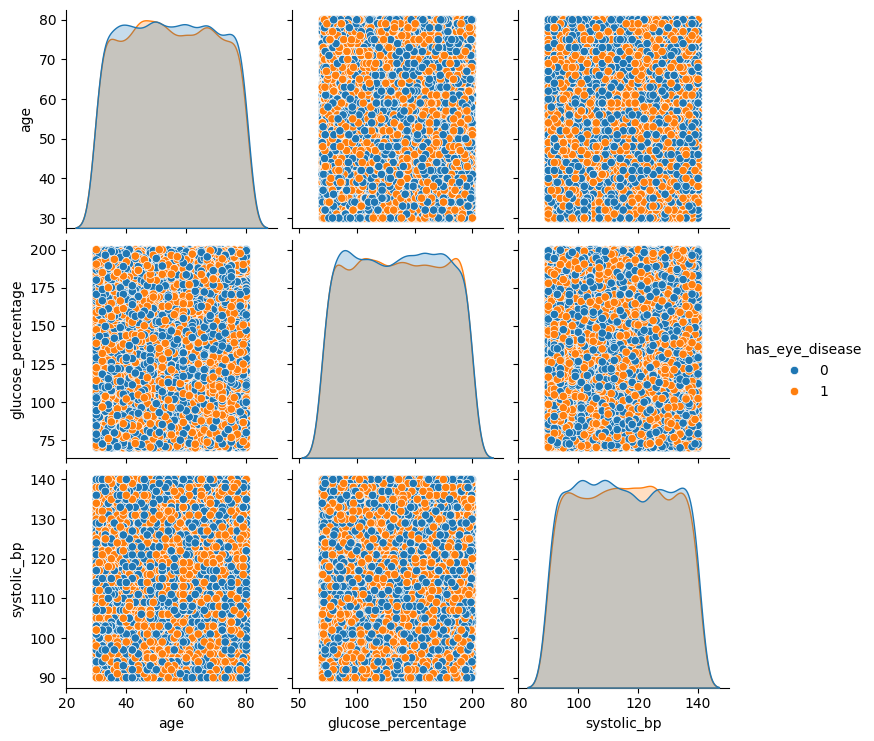

In [26]:
# Pairwise relationship plot for key clinical features grouped by eye disease presence
sns.pairplot(df[['age', 'glucose_percentage', 'systolic_bp', 'has_eye_disease']], hue='has_eye_disease'); plt.show()

### Modeling

In [27]:
x = df.drop(columns=['has_eye_disease'])
y = df['has_eye_disease']

In [28]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [29]:
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data only, then transform both train and test sets
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build a compact Neural Network to prevent vanishing gradients
model = Sequential([
    Dense(32, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

C:\Users\furka\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model using scaled training data
history = model.fit(
    x_train_scaled, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7095 - loss: 0.5321 - val_accuracy: 0.7375 - val_loss: 0.4935
Epoch 2/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7497 - loss: 0.4836 - val_accuracy: 0.7394 - val_loss: 0.4906
Epoch 3/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7531 - loss: 0.4773 - val_accuracy: 0.7394 - val_loss: 0.4887
Epoch 4/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7543 - loss: 0.4766 - val_accuracy: 0.7394 - val_loss: 0.4889
Epoch 5/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7542 - loss: 0.4755 - val_accuracy: 0.7394 - val_loss: 0.4890
Epoch 6/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7543 - loss: 0.4753 - val_accuracy: 0.7394 - val_loss: 0.4908
Epoch 7/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7544 - loss: 0.4744 - val_accuracy: 0.7394 - val_loss: 0.4886
Epoch 8/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7547 - loss: 0.4747 - val_accu

In [32]:
loss, accuracy=model.evaluate(x,y)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4935 - loss: 1578.8397


In [33]:
accuracy

0.4934999942779541

In [34]:
import matplotlib.pyplot as plt 

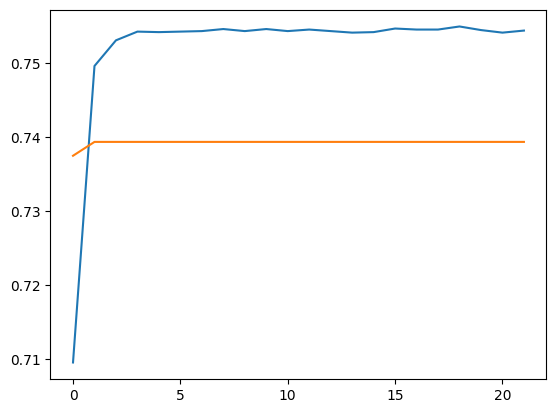

In [35]:
plt.plot(history.history['accuracy']) 
plt.plot(history.history['val_accuracy'])

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [37]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[2011    0]
 [ 991  998]]
LogisticRegression()  modeli eğitiliyor!..
[[1289  722]
 [ 860 1129]]
DecisionTreeClassifier()  modeli eğitiliyor!..


C:\Users\furka\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[[1299  712]
 [ 663 1326]]
RandomForestClassifier()  modeli eğitiliyor!..
[[1945   66]
 [ 959 1030]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[2005    6]
 [ 988 1001]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[1048  963]
 [1040  949]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[2011    0]
 [ 991  998]]
MultinomialNB()  modeli eğitiliyor!..
[[1317  694]
 [ 640 1349]]
Eğitim tamamlandı.
En başarılı model:  BernoulliNB
Confusion Matrix:
[[2011    0]
 [ 991  998]]
classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80      2011
           1       1.00      0.50      0.67      1989

    accuracy                           0.75      4000
   macro avg       0.83      0.75      0.74      4000
weighted avg       0.83      0.75      0.74      4000

Diğer Modeller:


,Accuracy,Precision,Recall,F1
BernoulliNB,0.75225,0.75225,0.75225,0.75225
AdaBoostClassifier,0.75225,0.75225,0.75225,0.75225
GradientBoostingClassifier,0.75150,0.75150,0.75150,0.75150
RandomForestClassifier,0.74375,0.74375,0.74375,0.74375
MultinomialNB,0.66650,0.66650,0.66650,0.66650
DecisionTreeClassifier,0.65625,0.65625,0.65625,0.65625
LogisticRegression,0.60450,0.60450,0.60450,0.60450
KNeighborsClassifier,0.49925,0.49925,0.49925,0.49925


Despite applying rigorous data preprocessing, standard scaling, and advanced domain-specific feature engineering (such as Pulse Pressure, Mean Arterial Pressure, and composite metabolic risk indices), the classification models reached a performance plateau at approximately 75% accuracy. This outcome highlights the inherent limitations of relying solely on general tabbed clinical variables (e.g., blood pressure, glucose levels, age) for complex eye disease prediction. Achieving higher diagnostic accuracy ($>90\%$) likely requires incorporating direct imaging modalities, such as retinal fundus photography or Optical Coherence Tomography (OCT) scans, alongside multi-modal deep learning architectures.